In [11]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import os
from hubble_utils import load_agn_data, read_quasars_from_hdf5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use('style.mplstyle')

from scipy.stats import linregress
from matplotlib.lines import Line2D

colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

def plot_stone_vs_this_work(
    merged_df,
    sigma_keys,  # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    tau_keys,    # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    show=True,
    figfile='plots/appendix/stone.png'
):

    ncols = len(bands)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.05)

    axes = np.atleast_2d(axes)

    def _limits(x, y, pad=0.04):
        lo = np.nanmin([np.nanmin(x), np.nanmin(y)])
        hi = np.nanmax([np.nanmax(x), np.nanmax(y)])
        rng = max(hi - lo, 1e-6)
        return lo - pad * rng, hi + pad * rng

    def _style(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.1)

        # agn_handle = Line2D([0], [0],
        #                     marker='o', linestyle='none',
        #                     mfc='k', mec='k', markersize=6,
        #                     label='AGN')
        ax.legend(
            loc='upper left', frameon=False, fancybox=True, framealpha=1,
                  edgecolor='0.2', facecolor='white', fontsize=11)

    def _maybe_get(df, pattern, band):
        if pattern is None:
            return None
        if isinstance(pattern, tuple):
            lo = df[pattern[0].format(band=band)].to_numpy()
            up = df[pattern[1].format(band=band)].to_numpy()
            return (lo, up)
        return df[pattern.format(band=band)].to_numpy()

    def _extract_xyerr(df, keydict, band):
        x = df[keydict['x'].format(band=band)].to_numpy()
        y = df[keydict['y'].format(band=band)].to_numpy()
        xerr = _maybe_get(df, keydict.get('xerr'), band)
        yerr = _maybe_get(df, keydict.get('yerr'), band)

        m = np.isfinite(x) & np.isfinite(y)
        if isinstance(xerr, tuple):
            m &= np.isfinite(xerr[0]) & np.isfinite(xerr[1])
        elif xerr is not None:
            m &= np.isfinite(xerr)
        if isinstance(yerr, tuple):
            m &= np.isfinite(yerr[0]) & np.isfinite(yerr[1])
        elif yerr is not None:
            m &= np.isfinite(yerr)

        if m.sum() == 0:
            return None

        x, y = x[m], y[m]
        if isinstance(xerr, tuple):
            xerr = (xerr[0][m], xerr[1][m])
        elif xerr is not None:
            xerr = xerr[m]
        if isinstance(yerr, tuple):
            yerr = (yerr[0][m], yerr[1][m])
        elif yerr is not None:
            yerr = yerr[m]
        return x, y, xerr, yerr

    # ---------- Top row: σ ----------
    for ax, band in zip(axes[0], bands):
        data = _extract_xyerr(merged_df, sigma_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8,
                   label='AGN')

        xmin, xmax = _limits(x, y)
        xmin, xmax = (-1.3, 0.1)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(sigma_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(sigma_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    # ---------- Bottom row: τ ----------
    for ax, band in zip(axes[1], bands):
        data = _extract_xyerr(merged_df, tau_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8,
                   label='AGN')

        xmin, xmax = _limits(x, y)
        xmin, xmax = (1.8, 4.2)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(tau_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(tau_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    for i in range(2):
        for j in range(1, ncols):
            axes[i, j].tick_params(labelleft=False)

    fig.savefig(figfile, dpi=600)


    if show:
        plt.show()
    plt.close(fig)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
def load_quasar_data(prefix):
    quasar_list = read_quasars_from_hdf5(f"results/data/{prefix}.h5")
    df = pd.DataFrame(quasar_list)
    df['object_id'] = df['object_id'].astype(str)
    # for band in ['g', 'r', 'i']:
    #     df = df[df[f'log_tau_band_{band}_RF'] > 1.5]
    return df


Reading quasars from HDF5:   0%|          | 0/184 [00:00<?, ?it/s]

Reading quasars from HDF5: 100%|██████████| 189/189 [00:01<00:00, 145.37it/s]


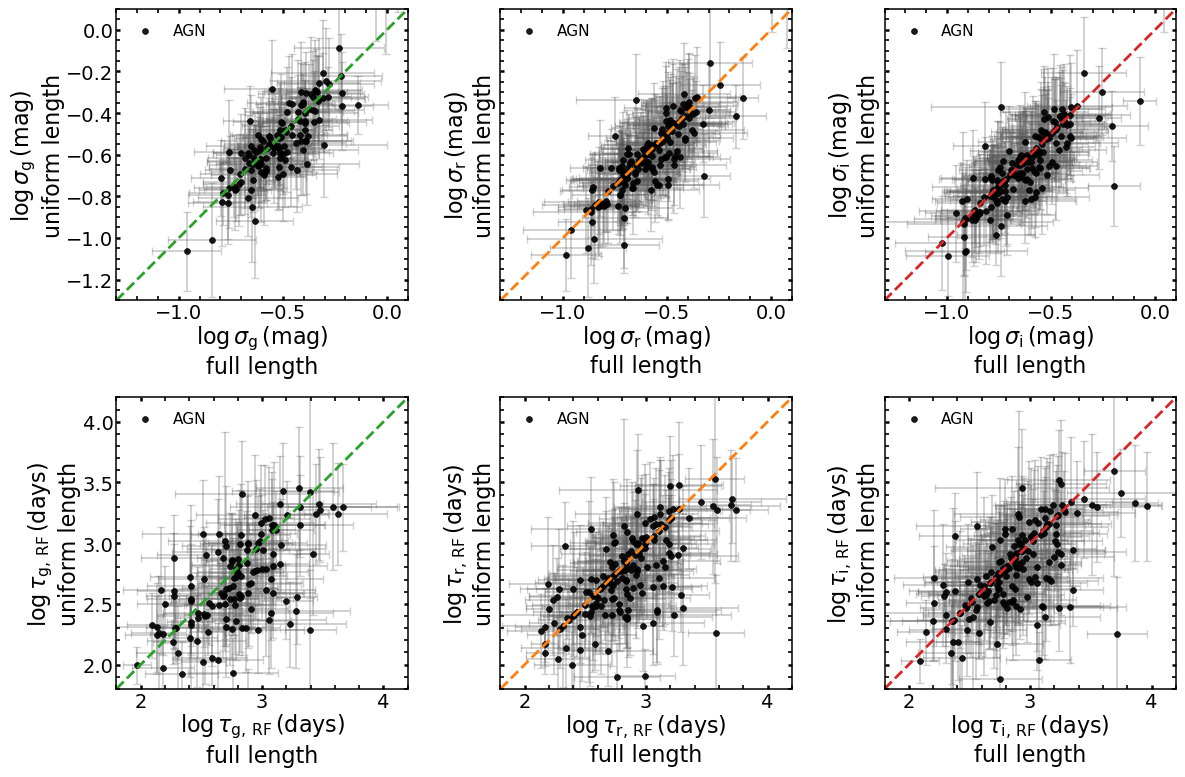

Reading quasars from HDF5: 100%|██████████| 189/189 [00:01<00:00, 143.21it/s]


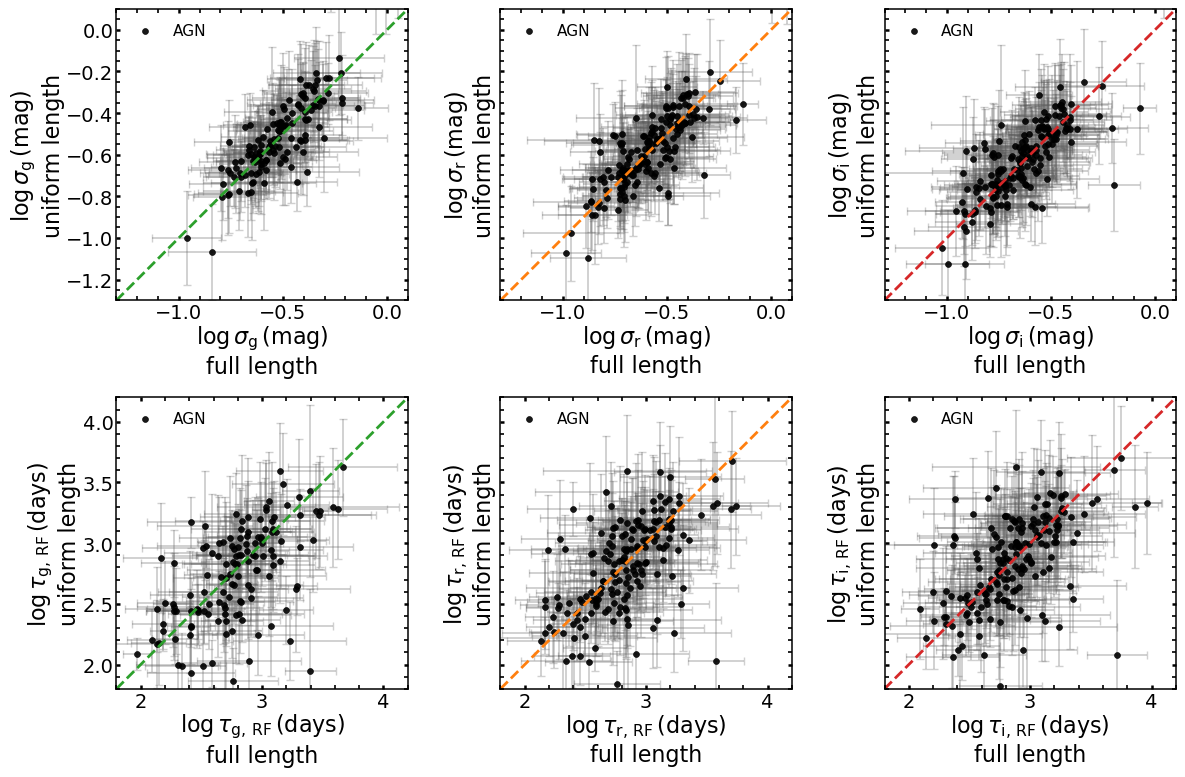

In [13]:
# Same length 
df_1 = load_quasar_data("oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4")

for prefix in [
    'oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_lmc-6_N1w1000s200t14ch4',
    'oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_nopoly1_lmc-6_N1w1000s200t14ch4'    
    ]:
    df_2 = load_quasar_data(prefix)

    merged_agn = pd.merge(df_1, df_2, on='object_id', how='inner', suffixes=('_1', '_2'))

    # New fit compare
    sigma_keys = {
        'x': 'log_sigma_band_{band}_1',
        'y': 'log_sigma_band_{band}_2',
        'xerr': 'log_sigma_band_{band}_err_1',
        'yerr': 'log_sigma_band_{band}_err_2',
        'xlabel': r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$' + '\nfull length',
        'ylabel': r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$' + '\nuniform length',
    }

    tau_keys = {
        'x': 'log_tau_band_{band}_RF_1',
        'y': 'log_tau_band_{band}_RF_2',
        'xerr': 'log_tau_band_{band}_RF_err_1',
        'yerr': 'log_tau_band_{band}_RF_err_2',
        'xlabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\nfull length',
        'ylabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\nuniform length',
    }


    plot_stone_vs_this_work(merged_agn, sigma_keys, tau_keys, bands=('g','r','i'), figfile=f"plots/appendix/stone_tests/stonelcs_samelength_{prefix}.pdf")

Reading quasars from HDF5: 100%|██████████| 184/184 [00:01<00:00, 147.24it/s]


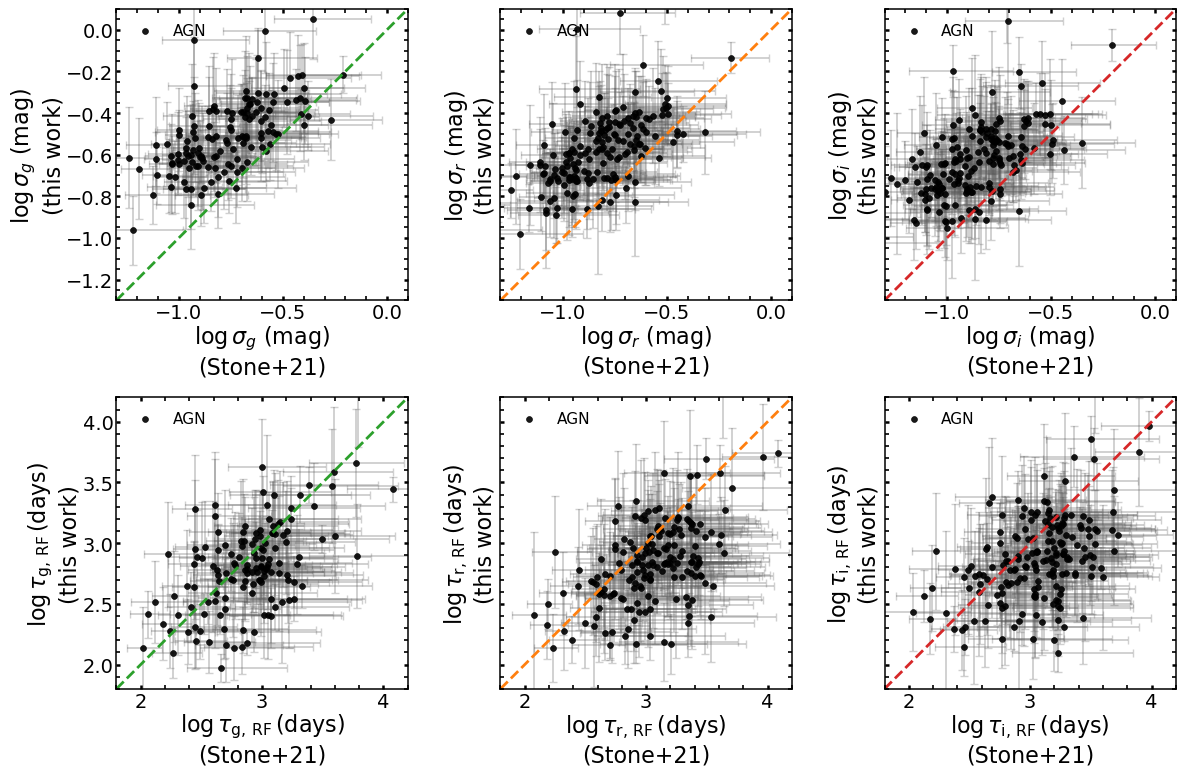

Reading quasars from HDF5: 100%|██████████| 189/189 [00:01<00:00, 150.27it/s]


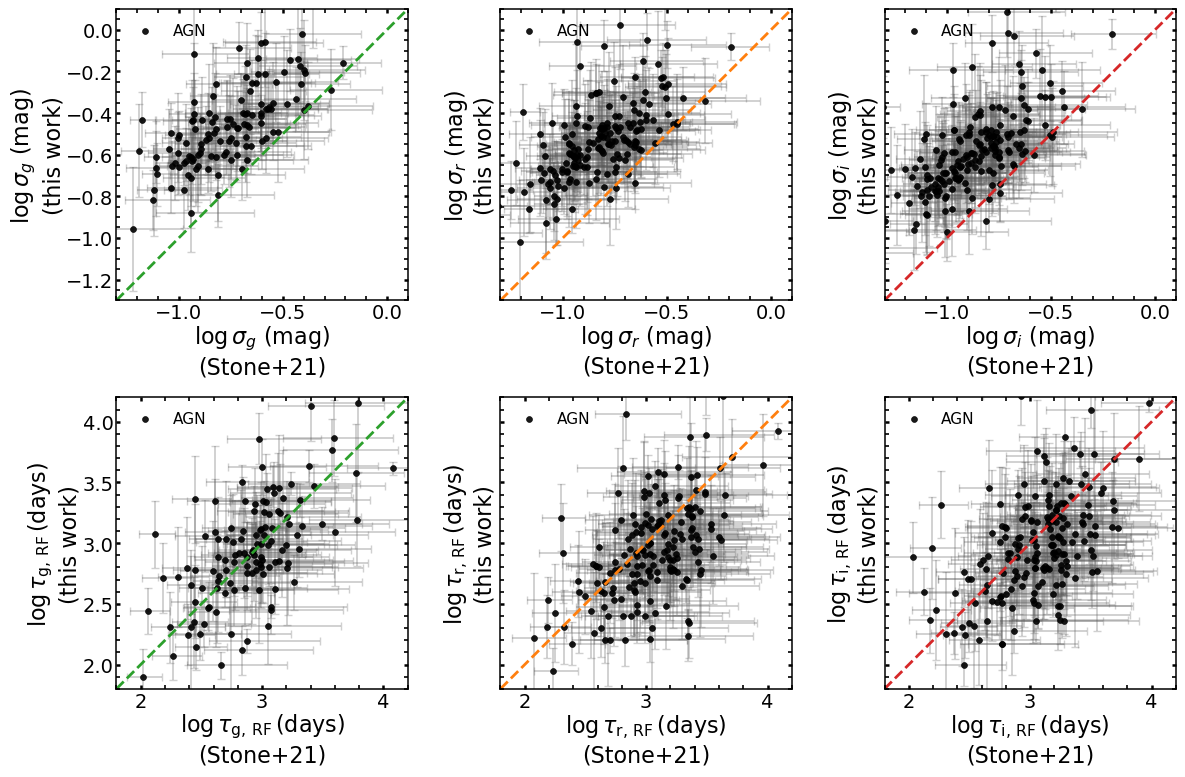

In [14]:
# Stone vs Stone LCs fitted no lag blr
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log\!\,\sigma_{{{band}}}$ (mag)' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\sigma_{{{band}}}$ (mag)' + '\n(this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\n(this work)',
}

for prefix in [
    "oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4",
    "oct26a_carma_single_lagblrband_stoneyu_spl_nofhost_bwb_taufasttruncated_nopoly1_lmc-6_N1w1000s200t14ch4",
    ]:
    #"oct22a_single_stoneyu_lagblrband_stoneyu_spl_nofhost_lmc-6_N1w2000s400t14ch4",
    #"oct23a_single_stoneyu_lagblrband_stoneyu_spl_nofhost_nopoly1_lmc-6_N1w2000s400t14ch4",

    # Load stone data
    stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
    stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

    df_agn = load_quasar_data(prefix)

    os.makedirs("plots/appendix/stone_tests", exist_ok=True)
    merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
    plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile=f"plots/appendix/stone_tests/stonelcs_stonetest_{prefix}_mixed.pdf")